In [1]:
import qm9.data.prepare.download as download

In [2]:
import logging
import sys

logging.basicConfig(
    level=logging.INFO,
    stream=sys.stdout,
    format="%(levelname)s:%(name)s:%(message)s",
    force=True,   # important in notebooks
)

In [3]:
logging.info('Dataset exists and is processed.')

INFO:root:Dataset exists and is processed.


In [4]:
download.prepare_dataset(datadir = './downloaded_data/', dataset = "qm9", cleanup=False)

INFO:root:Dataset exists and is processed.


{'train': './downloaded_data/qm9/train.npz',
 'valid': './downloaded_data/qm9/valid.npz',
 'test': './downloaded_data/qm9/test.npz'}

In [5]:
import numpy as np
traindata = np.load('./downloaded_data/qm9/train.npz')

In [6]:
print(traindata.files)


['num_atoms', 'charges', 'positions', 'index', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'U0', 'U', 'H', 'G', 'Cv', 'omega1', 'zpve_thermo', 'U0_thermo', 'U_thermo', 'H_thermo', 'G_thermo', 'Cv_thermo']


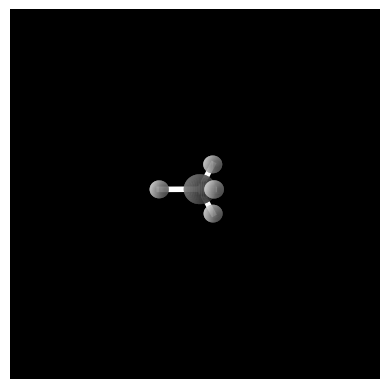

In [30]:
import torch
import numpy as np
import qm9.visualizer as visualizer

# atomic number -> plotting index
z_to_idx = {1: 0, 6: 1, 7: 2, 8: 3, 9: 4}

dataset_info = {
    'name': 'qm9',
    'atom_decoder': ['H', 'C', 'N', 'O', 'F'],
    'atom_encoder': {'H': 0, 'C': 1, 'N': 2, 'O': 3, 'F': 4},
    'colors_dic': ['#FFFFFF', '#909090', '#3050F8', '#FF0D0D', '#90E050'],
    'radius_dic': [0.46, 0.77, 0.75, 0.73, 0.71],
}

i = 0
n = int(traindata['num_atoms'][i])

positions = torch.tensor(traindata['positions'][i][:n], dtype=torch.float32)
positions = positions - positions.mean(dim=0, keepdim=True)   # optional centering

charges = traindata['charges'][i][:n]
# charges = [1,1,1,1,6]
atom_type = np.array([z_to_idx[int(z)] for z in charges])

visualizer.plot_data3d(
    positions,
    atom_type,
    dataset_info=dataset_info,
    spheres_3d=True
)

In [9]:
import numpy as np
import qm9.analyze as analyze

QM9_DATASET_INFO = {
    'name': 'qm9',
    'atom_decoder': ['H', 'C', 'N', 'O', 'F'],
    'atom_encoder': {'H': 0, 'C': 1, 'N': 2, 'O': 3, 'F': 4},
}

ATOMIC_NUMBER_TO_TYPE = {
    1: 0,  # H
    6: 1,  # C
    7: 2,  # N
    8: 3,  # O
    9: 4,  # F
}

def check_sample_validity(positions, charges, num_atoms=None, debug=False):
    """
    Check QM9 sample validity/stability using the uploaded analyze.check_stability.

    Args:
        positions: array-like, shape (N, 3)
        charges: array-like, shape (N,), atomic numbers with possible zero padding
        num_atoms: optional int, number of real atoms
        debug: passed to analyze.check_stability

    Returns:
        dict with molecule_stable, atom_stable_count, num_atoms
    """
    positions = np.asarray(positions, dtype=float)
    charges = np.asarray(charges, dtype=int)

    if num_atoms is not None:
        positions = positions[:num_atoms]
        charges = charges[:num_atoms]
    else:
        mask = charges > 0
        positions = positions[mask]
        charges = charges[mask]

    atom_type = np.array([ATOMIC_NUMBER_TO_TYPE[int(z)] for z in charges], dtype=int)

    molecule_stable, atom_stable_count, total_atoms = analyze.check_stability(
        positions=positions,
        atom_type=atom_type,
        dataset_info=QM9_DATASET_INFO,
        debug=debug,
    )

    return {
        "molecule_stable": bool(molecule_stable),
        "atom_stable_count": int(atom_stable_count),
        "num_atoms": int(total_atoms),
        "atom_fraction_stable": float(atom_stable_count) / float(total_atoms) if total_atoms > 0 else 0.0,
    }

In [10]:
for i in range(1):
    # i = 10
    result = check_sample_validity(
        positions=traindata['positions'][i],
        charges=traindata['charges'][i],
        # charges=[1,1,1,1,6],
        num_atoms=int(traindata['num_atoms'][i]),
        debug=True,
    )

    print(result)

{'molecule_stable': True, 'atom_stable_count': 5, 'num_atoms': 5, 'atom_fraction_stable': 1.0}


In [11]:
import torch
from egnn.models import EGNN_dynamics_QM9

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bs = 2
n_nodes = 8          # padded size
n_valid = 5          # actual number of atoms
n_dims = 3

raw_h_dims = 5       # only atom-type one-hot in xh
condition_time = True

# Constructor expects raw_h_dims + 1 because time is appended internally
model_in_node_nf = raw_h_dims + int(condition_time)   # 6

model = EGNN_dynamics_QM9(
    in_node_nf=model_in_node_nf,
    context_node_nf=0,
    n_dims=n_dims,
    hidden_nf=64,
    device=device,
    n_layers=4,
    attention=False,
    condition_time=condition_time,
    mode="egnn_dynamics",
).to(device)

model.eval()

# ----------------------------
# Create padded input
# first 5 nodes are real, last 3 are padded zeros
# ----------------------------
x = torch.zeros(bs, n_nodes, n_dims, device=device)
h = torch.zeros(bs, n_nodes, raw_h_dims, device=device)

x[:, :n_valid, :] = torch.randn(bs, n_valid, n_dims, device=device)
h[:, :n_valid, :] = torch.randn(bs, n_valid, raw_h_dims, device=device)

xh = torch.cat([x, h], dim=2)   # shape (bs, 8, 8)

# Random continuous time
t = torch.rand(bs, device=device)

# ----------------------------
# Masks
# ----------------------------
node_mask = torch.zeros(bs, n_nodes, 1, device=device)
node_mask[:, :n_valid, :] = 1.0

# edge_mask[i,j] = 1 only if both nodes are valid
edge_mask = node_mask.unsqueeze(2) * node_mask.unsqueeze(1)   # (bs, 8, 8, 1)

with torch.no_grad():
    out = model._forward(t, xh, node_mask, edge_mask, context=None)

print("xh shape:       ", xh.shape)
print("node_mask shape:", node_mask.shape)
print("edge_mask shape:", edge_mask.shape)
print("out shape:      ", out.shape)

print("valid output shape: ", out[:, :n_valid, :].shape)
print("padded output max abs:",
      out[:, n_valid:, :].abs().max().item())

xh shape:        torch.Size([2, 8, 8])
node_mask shape: torch.Size([2, 8, 1])
edge_mask shape: torch.Size([2, 8, 8, 1])
out shape:       torch.Size([2, 8, 8])
valid output shape:  torch.Size([2, 5, 8])
padded output max abs: 0.0


In [12]:
import numpy as np


# QM9 atomic number -> one-hot index
Z_TO_IDX = {
    1: 0,  # H
    6: 1,  # C
    7: 2,  # N
    8: 3,  # O
    9: 4,  # F
}


def save_qm9_minimal_npz(
    data,
    save_path,
    max_nodes=29,
    center_positions=True,
    dtype=np.float32,
):
    """
    Save only the necessary QM9 training data to a .npz file.

    Input `data` is expected to contain:
        data['positions']: shape [N, M, 3]
        data['charges']:   shape [N, M] with values in {0,1,6,7,8,9}
        data['num_atoms']: shape [N]

    Output saved to .npz:
        xh:        [N, max_nodes, 8] = [x, y, z, onehot(H,C,N,O,F)]
        num_atoms: [N]

    Notes:
    - padded rows are zero
    - node_mask is NOT saved
    - edge_mask is NOT saved
    - both can be rebuilt later from num_atoms
    """
    positions = np.asarray(data["positions"], dtype=dtype)
    charges = np.asarray(data["charges"], dtype=np.int64)
    num_atoms = np.asarray(data["num_atoms"], dtype=np.int64)

    if positions.ndim != 3 or positions.shape[-1] != 3:
        raise ValueError(f"positions must have shape [N, M, 3], got {positions.shape}")
    if charges.ndim != 2:
        raise ValueError(f"charges must have shape [N, M], got {charges.shape}")
    if num_atoms.ndim != 1:
        raise ValueError(f"num_atoms must have shape [N], got {num_atoms.shape}")

    N, M, D = positions.shape

    if charges.shape != (N, M):
        raise ValueError(
            f"charges shape {charges.shape} must match first two dims of positions {(N, M)}"
        )
    if num_atoms.shape[0] != N:
        raise ValueError(
            f"num_atoms length {num_atoms.shape[0]} must match positions batch size {N}"
        )

    if np.max(num_atoms) > max_nodes:
        raise ValueError(
            f"max num_atoms is {np.max(num_atoms)}, but max_nodes={max_nodes}"
        )

    allowed = np.array([0, 1, 6, 7, 8, 9])
    unique_vals = np.unique(charges)
    if not np.all(np.isin(unique_vals, allowed)):
        raise ValueError(
            f"Unexpected values in charges: {unique_vals}. Expected subset of {allowed}."
        )

    # Final training tensor: [N, max_nodes, 8]
    # 8 = 3 coords + 5 one-hot atom-type channels
    xh = np.zeros((N, max_nodes, 8), dtype=dtype)

    for i in range(N):
        n = int(num_atoms[i])

        pos = positions[i, :n].astype(dtype, copy=True)
        z = charges[i, :n]

        if center_positions and n > 0:
            pos = pos - pos.mean(axis=0, keepdims=True)

        one_hot = np.zeros((n, 5), dtype=dtype)
        for j in range(n):
            atomic_number = int(z[j])
            if atomic_number not in Z_TO_IDX:
                raise ValueError(
                    f"Sample {i}, atom {j}: unsupported atomic number {atomic_number}"
                )
            one_hot[j, Z_TO_IDX[atomic_number]] = 1.0

        xh[i, :n, :3] = pos
        xh[i, :n, 3:] = one_hot

    np.savez_compressed(
        save_path,
        xh=xh,
        num_atoms=num_atoms,
    )

    print(f"Saved to: {save_path}")
    print(f"xh shape: {xh.shape}")
    print(f"num_atoms shape: {num_atoms.shape}")


def load_qm9_minimal_npz(path):
    """
    Load the saved minimal dataset.
    """
    data = np.load(path)
    xh = data["xh"]          # [N, max_nodes, 8]
    num_atoms = data["num_atoms"]  # [N]
    return xh, num_atoms


def build_masks_from_num_atoms(num_atoms, max_nodes):
    """
    Rebuild masks when needed.

    Args:
        num_atoms: [B]
        max_nodes: int

    Returns:
        node_mask: [B, max_nodes, 1]
        edge_mask: [B, max_nodes, max_nodes, 1]
    """
    num_atoms = np.asarray(num_atoms, dtype=np.int64)

    node_mask = (np.arange(max_nodes)[None, :] < num_atoms[:, None]).astype(np.float32)
    node_mask = node_mask[..., None]  # [B, max_nodes, 1]

    edge_mask = node_mask[:, :, None, :] * node_mask[:, None, :, :]  # [B, max_nodes, max_nodes, 1]
    return node_mask, edge_mask

In [13]:
testdata = np.load('./downloaded_data/qm9/test.npz')

save_qm9_minimal_npz(testdata, "./downloaded_data/qm9/test_processed.npz")

Saved to: ./downloaded_data/qm9/test_processed.npz
xh shape: (13083, 29, 8)
num_atoms shape: (13083,)


In [14]:
import load_data
import PDFM
import numpy as np
qm9 = load_data.qm9dataset()



### load the model

In [18]:
import torch
# ckpt = torch.load('./saved_model/PDFM0p0_5000.pth', weights_only=True)

PDFM_class = PDFM.PDFlowMatching(qm9)
# ckpt = torch.load('./saved_model/FM192t4/FM192t4_4_64p28.pth', weights_only=True)
ckpt = torch.load('./saved_model/FM192_t3_35000.pth', weights_only=True)

# PDFM_class = PDFM.PDFlowMatching(qm9)
# ckpt = torch.load('./saved_model/default/FM256_t2_70000.pth', weights_only=True)
# ckpt = torch.load('./saved_model/FM256v1/FM256v1_2_21p31.pth', weights_only=True)
PDFM_class.model.load_state_dict(ckpt)


<All keys matched successfully>

### Evaluations and Visualizations

In [ ]:
res_bool_record = np.zeros(10)
res_percent_record = np.zeros(10)
for i in range(1):
    print(i)
    batch_size = 1
    # num_atoms = torch.tensor([5,5,5,5,6], device = PDFM_class.device)
    # batch_size = num_atoms.shape[0]
    # num_atoms = torch.ones(batch_size, device = PDFM_class.device)*4
    num_atoms = qm9.sample_num_atoms(batch_size)
    
    
    
    res = PDFM_class.sampler(batch_size, num_atoms)
    resnp = res.cpu().numpy()
    
    res_bool, res_percent = qm9.check_molecule_stable_batch(res, debug = False)
    res_bool_record[i] = torch.sum(res_bool).item()
    res_percent_record[i] = torch.sum(res_percent).item()
    # print(torch.sum(res_bool))
    # print(torch.mean(res_percent))

In [ ]:
for i in range(10):
    print(PDFM_class.estimate_nll(qm9, 100, return_mean = True))

In [ ]:
print(np.mean(res_bool_record/1000))
print(np.std(res_bool_record/1000))

print(np.mean(res_percent_record/1000))
print(np.std(res_percent_record/1000))

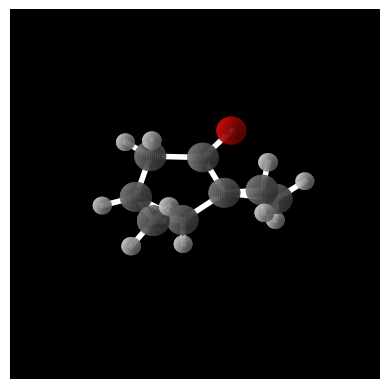

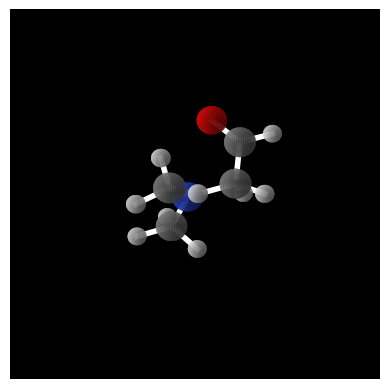

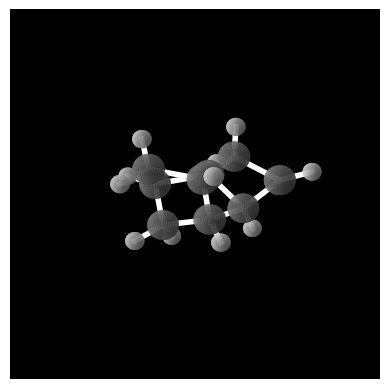

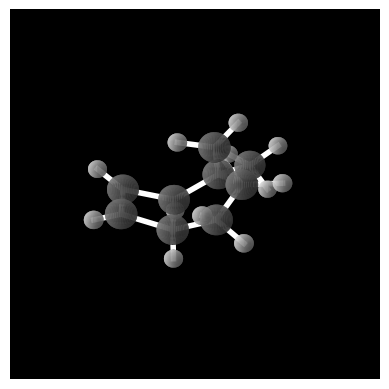

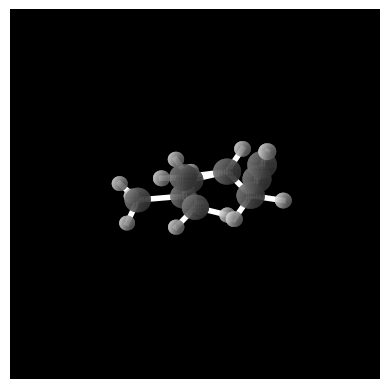

In [10]:
%matplotlib inline
qm9.viz_xh(res[:5])